In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# PART B - FINANCIAL TIME SERIES FORECASTING USING NEURAL NETWORKS
# Dataset: EUR/USD 5-Minute Financial Data
# Objective: Predict Next Candle Close Price
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn preprocessing and evaluation metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TensorFlow / Keras for Deep Learning Models
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

In [28]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

# Load CSV file exported from Dukascopy
df = pd.read_csv('/content/drive/MyDrive/PART_B/Dataset/EURUSD_5 Mins_Bid_2025.10.01_2026.03.31.csv')

# Normalize raw column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace('<', '', regex=False)
    .str.replace('>', '', regex=False)
    .str.replace(' ', '_')
)

print("Original Columns:")
print(df.columns.tolist())

Original Columns:
['time_(eet)', 'open', 'high', 'low', 'close', 'volume']


In [38]:
# ============================================================
# 3. PREPROCESS DATETIME COLUMN
# ============================================================

# Rename time column to standard datetime
df.rename(columns={'time_(eet)': 'datetime'}, inplace=True)

# Convert to datetime type
df['datetime'] = pd.to_datetime(df['datetime'])

# Sort by time
df = df.sort_values('datetime')

# Set datetime as index
df.set_index('datetime', inplace=True)

In [39]:
# ============================================================
# 4. BASIC DATA EXPLORATION
# ============================================================

print("Dataset Shape:", df.shape)
print(df.info())
print(df.isnull().sum())

Dataset Shape: (36984, 5)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 36984 entries, 2025-10-01 00:00:00 to 2026-03-31 23:55:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    36984 non-null  float64
 1   high    36984 non-null  float64
 2   low     36984 non-null  float64
 3   close   36984 non-null  float64
 4   volume  36984 non-null  float64
dtypes: float64(5)
memory usage: 1.7 MB
None
open      0
high      0
low       0
close     0
volume    0
dtype: int64


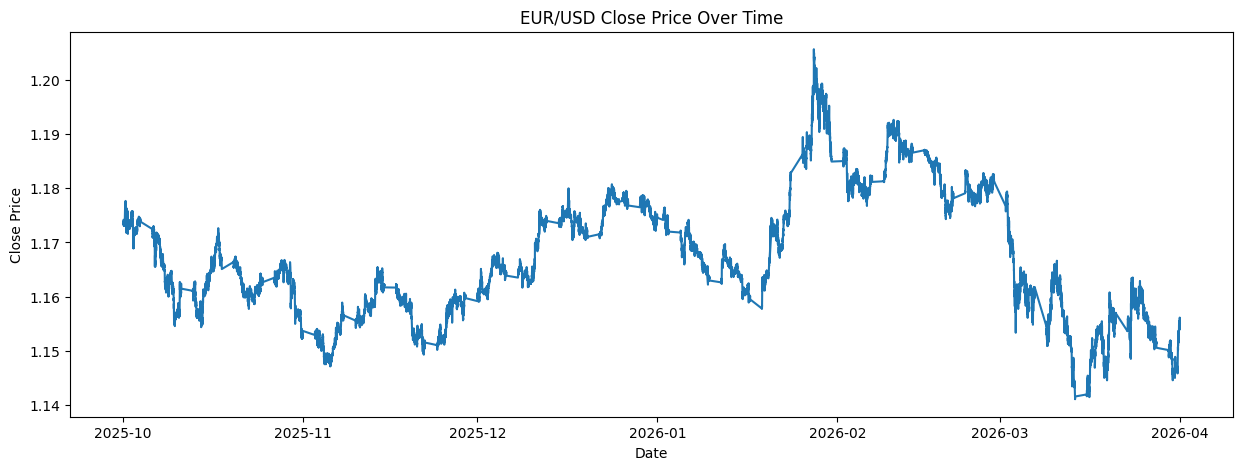

In [40]:
# ============================================================
# 5. VISUALIZE CLOSE PRICE
# ============================================================

plt.figure(figsize=(15,5))
plt.plot(df['close'])
plt.title('EUR/USD Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

In [41]:
# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================

# Moving Averages
df['ma_10'] = df['close'].rolling(10).mean()
df['ma_30'] = df['close'].rolling(30).mean()

# RSI Calculation
delta = df['close'].diff()

gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()

rs = gain / loss

df['rsi'] = 100 - (100 / (1 + rs))

# Volatility
df['volatility'] = df['close'].rolling(10).std()

# Remove NaNs from rolling indicators
df.dropna(inplace=True)

In [42]:
# ============================================================
# 7. DEFINE FEATURES AND TARGET
# ============================================================

features = [
    'open',
    'high',
    'low',
    'close',
    'volume',
    'ma_10',
    'ma_30',
    'rsi',
    'volatility'
]

X_raw = df[features]

# Predict next candle close price
y_raw = df['close'].shift(-1)

# Remove final NaN target row
X_raw = X_raw[:-1]
y_raw = y_raw[:-1]

In [43]:
# ============================================================
# 8. SCALE DATA
# ============================================================

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw.values.reshape(-1,1))

In [44]:
# ============================================================
# 9. CREATE TIME SERIES SEQUENCES
# ============================================================

SEQ_LEN = 30

X_seq = []
y_seq = []

for i in range(SEQ_LEN, len(X_scaled)):

    X_seq.append(X_scaled[i-SEQ_LEN:i])
    y_seq.append(y_scaled[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("Sequence Shape:", X_seq.shape)
print("Target Shape:", y_seq.shape)

Sequence Shape: (36924, 30, 9)
Target Shape: (36924, 1)


In [45]:
# ============================================================
# 10. TRAIN / TEST SPLIT
# ============================================================

split_index = int(len(X_seq) * 0.8)

X_train = X_seq[:split_index]
X_test  = X_seq[split_index:]

y_train = y_seq[:split_index]
y_test  = y_seq[split_index:]

In [46]:
# ============================================================
# 11. ANN BASELINE MODEL
# ============================================================

ann = models.Sequential([

    layers.Flatten(input_shape=X_train.shape[1:]),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(64, activation='relu'),

    layers.Dense(1)
])

ann.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [47]:
# ============================================================
# 12. LSTM MODEL
# ============================================================

lstm = models.Sequential([

    layers.LSTM(
        64,
        return_sequences=True,
        input_shape=X_train.shape[1:]
    ),

    layers.Dropout(0.2),

    layers.LSTM(32),

    layers.Dropout(0.2),

    layers.Dense(1)
])

lstm.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [49]:
# ============================================================
# 13. CNN-LSTM MODEL
# ============================================================

cnn_lstm = models.Sequential([

    layers.Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=X_train.shape[1:]
    ),

    layers.MaxPooling1D(2),

    layers.LSTM(64),

    layers.Dropout(0.2),

    layers.Dense(1)
])

cnn_lstm.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
# ============================================================
# 14. EARLY STOPPING
# ============================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [51]:
# ============================================================
# 15. TRAIN ALL MODELS
# ============================================================

hist_ann = ann.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

hist_lstm = lstm.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

hist_cnn = cnn_lstm.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
370/370 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0038 - mae: 0.0369 - val_loss: 0.0122 - val_mae: 0.1083
Epoch 2/100
370/370 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 5.9432e-04 - mae: 0.0182 - val_loss: 0.0113 - val_mae: 0.1044
Epoch 3/100
370/370 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 3.3464e-04 - mae: 0.0132 - val_loss: 0.0190 - val_mae: 0.1361
Epoch 4/100
370/370 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 2.2042e-04 - mae: 0.0106 - val_loss: 0.0195 - val_mae: 0.1381
Epoch 5/100
370/370 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.7799e-04 - mae: 0.0096 - val_loss: 0.0195 - val_mae: 0.1381
Epoch 6/100
370/370 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.4074e-04 - mae: 0.0085 - val_loss: 0.0195 - val_mae: 0.1382
Epoch 7/100
370/370 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.1373e-04 - mae: 0.0077 - val_loss: 0.0282 - val_mae: 0.1662
Epoch 8/100
370/370 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.0280e-04 - mae: 0.0074 - val_loss: 0.0215 - val_mae: 0.1452
Epoch 9/100
370/370 

In [52]:
# ============================================================
# 16. EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, X_test, y_test, scaler_y):

    preds = model.predict(X_test)

    preds_inv = scaler_y.inverse_transform(preds)
    y_test_inv = scaler_y.inverse_transform(y_test)

    mae = mean_absolute_error(y_test_inv, preds_inv)
    rmse = np.sqrt(mean_squared_error(y_test_inv, preds_inv))
    r2 = r2_score(y_test_inv, preds_inv)

    return mae, rmse, r2, preds_inv, y_test_inv

In [53]:
# ============================================================
# 17. EVALUATE MODELS
# ============================================================

results = {}

for name, model in {
    'ANN': ann,
    'LSTM': lstm,
    'CNN-LSTM': cnn_lstm
}.items():

    mae, rmse, r2, preds, true = evaluate_model(
        model,
        X_test,
        y_test,
        scaler_y
    )

    results[name] = [mae, rmse, r2]

results_df = pd.DataFrame(
    results,
    index=['MAE', 'RMSE', 'R2']
).T

print(results_df)

231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
               MAE      RMSE        R2
ANN       0.002940  0.003406  0.892577
LSTM      0.000502  0.000698  0.995494
CNN-LSTM  0.000547  0.000787  0.994273


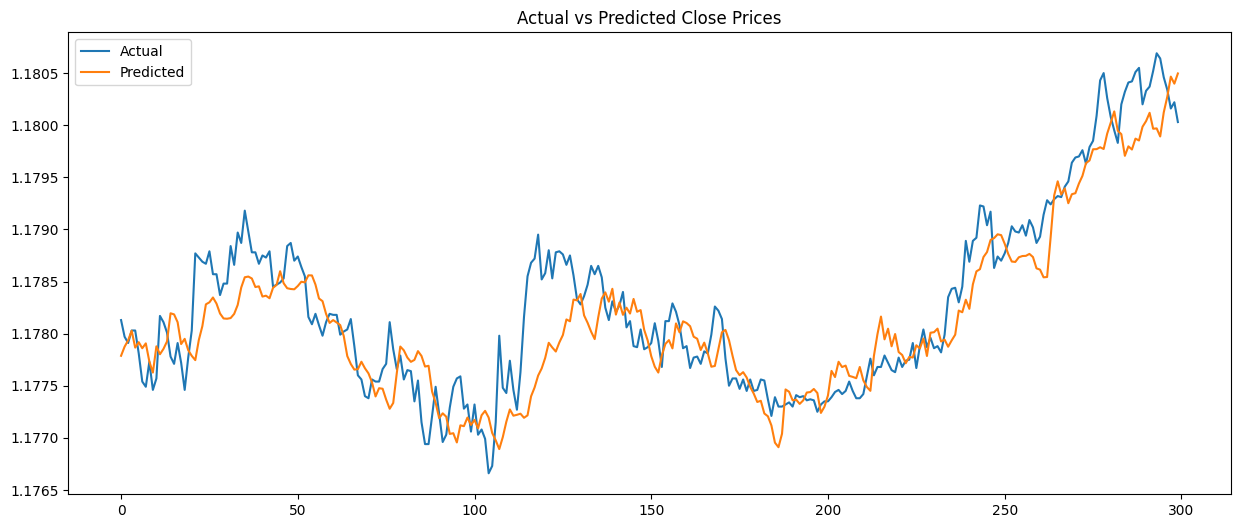

In [54]:
# ============================================================
# 18. PLOT PREDICTIONS
# ============================================================

plt.figure(figsize=(15,6))

plt.plot(true[:300], label='Actual')
plt.plot(preds[:300], label='Predicted')

plt.legend()
plt.title('Actual vs Predicted Close Prices')

plt.show()

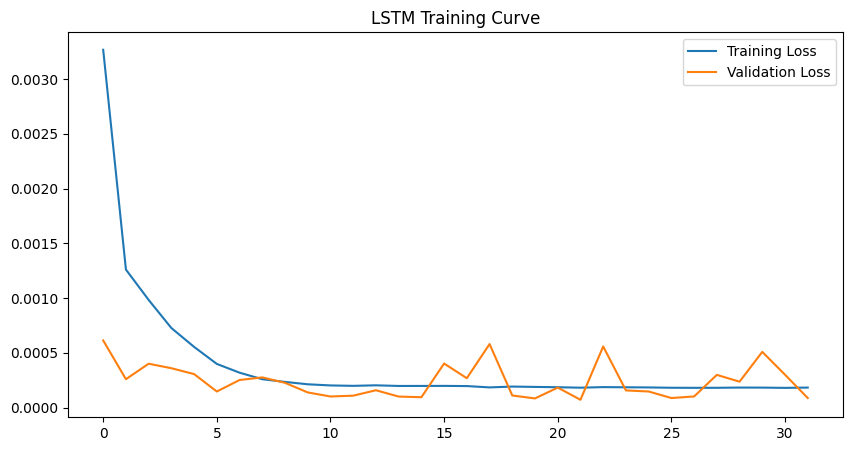

In [55]:
# ============================================================
# 19. TRAINING CURVE
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(hist_lstm.history['loss'], label='Training Loss')
plt.plot(hist_lstm.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title('LSTM Training Curve')

plt.show()

In [ ]:
# ============================================================
# 20. HYPERPARAMETER OPTIMIZATION
# ============================================================

units_list = [32, 64, 128]
dropouts = [0.1, 0.2, 0.3]

best_loss = np.inf
best_params = None

for units in units_list:
    for drop in dropouts:

        model = models.Sequential([
            layers.LSTM(units, input_shape=X_train.shape[1:]),
            layers.Dropout(drop),
            layers.Dense(1)
        ])

        model.compile(
            optimizer='adam',
            loss='mse'
        )

        hist = model.fit(
            X_train,
            y_train,
            validation_split=0.2,
            epochs=20,
            batch_size=64,
            verbose=0
        )

        val_loss = min(hist.history['val_loss'])

        if val_loss < best_loss:
            best_loss = val_loss
            best_params = (units, drop)

print("Best Hyperparameters Found:")
print("Units:", best_params[0])
print("Dropout:", best_params[1])